In [2]:
! pip install yfinance


In [3]:
! pip install matplotlib


In [4]:
import yfinance as yf 
import pandas as pd 
import matplotlib.pyplot as plt 


In [5]:
tickers = {"appl", "msft", "spy" } 


In [6]:
tickers = ["AAPL", "MSFT", "^GSPC"]

prices = yf.download(tickers, start="2020-01-01")["Close"]

prices.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,MSFT,^GSPC
Date,,,
2020-01-02,72.400505,152.158432,3257.850098
2020-01-03,71.696617,150.263779,3234.850098
2020-01-06,72.267921,150.652145,3246.280029
2020-01-07,71.928032,149.278534,3237.179932
2020-01-08,73.085114,151.656326,3253.050049


In [7]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AAPL,MSFT,^GSPC
Date,,,
2020-01-03,-0.009722,-0.012452,-0.007060
2020-01-06,0.007968,0.002585,0.003533
2020-01-07,-0.004703,-0.009118,-0.002803
2020-01-08,0.016087,0.015929,0.004902
2020-01-09,0.021241,0.012493,0.006655


In [8]:
returns.mean()

Ticker
AAPL     0.001029
MSFT     0.000823
^GSPC    0.000582
dtype: float64

In [9]:
returns.std()

Ticker
AAPL     0.019848
MSFT     0.018743
^GSPC    0.013010
dtype: float64

In [10]:
sharpe = returns.mean() / returns.std()
sharpe

Ticker
AAPL     0.051870
MSFT     0.043930
^GSPC    0.044754
dtype: float64

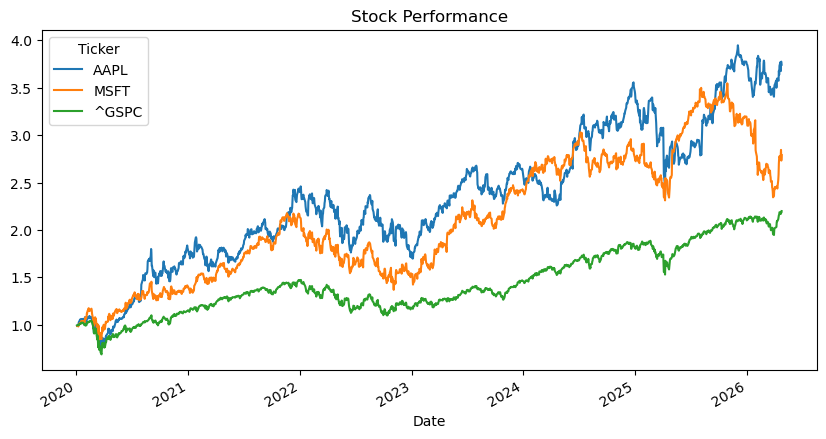

In [11]:
(1 + returns).cumprod().plot(figsize=(10,5))
plt.title("Stock Performance")
plt.show() 

[*********************100%***********************]  3 of 3 completed


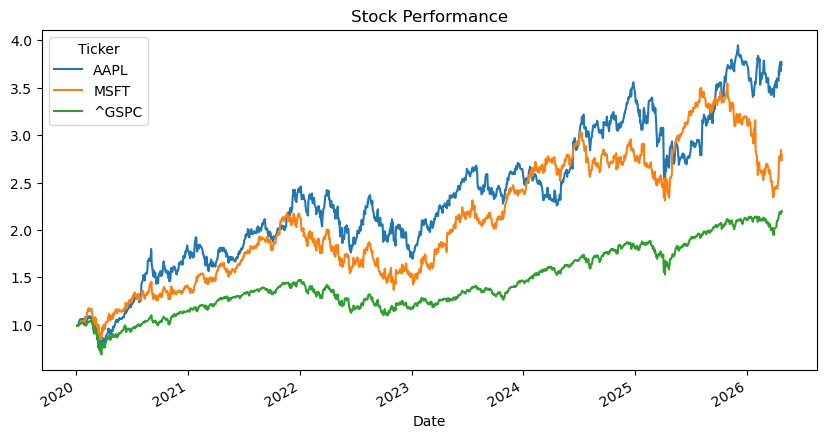

In [12]:
# 1. Import
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 2. Data
tickers = ["AAPL", "MSFT", "^GSPC"]
prices = yf.download(tickers, start="2020-01-01")["Close"]

# 3. Returns
returns = prices.pct_change().dropna()

# 4. Sharpe
sharpe = returns.mean() / returns.std()

# 5. Plot
(1 + returns).cumprod().plot(figsize=(10,5))
plt.title("Stock Performance")
plt.show()

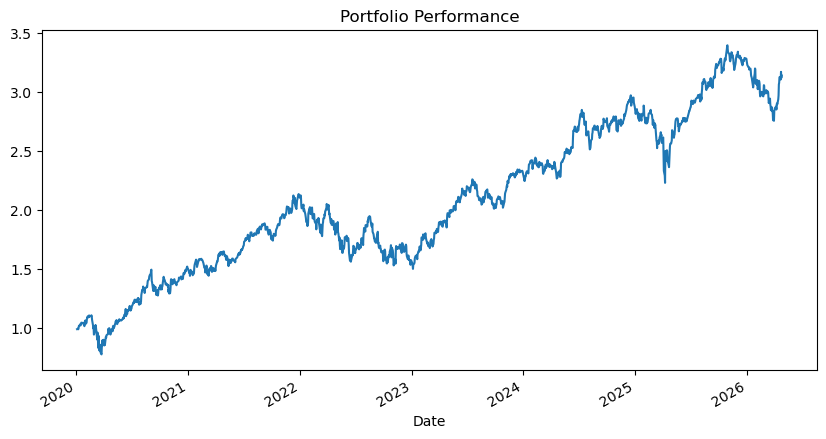

In [13]:
weights = [0.4, 0.4, 0.2]  # AAPL, MSFT, S&P

portfolio_returns = returns.dot(weights)

(1 + portfolio_returns).cumprod().plot(figsize=(10,5))
plt.title("Portfolio Performance")
plt.show()

In [14]:
annual_return = returns.mean() * 252
annual_volatility = returns.std() * (252 ** 0.5)

summary = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility,
    "Sharpe Ratio": sharpe
})

summary

,Annual Return,Annual Volatility,Sharpe Ratio
Ticker,,,
AAPL,0.259434,0.315073,0.051870
MSFT,0.207490,0.297531,0.043930
^GSPC,0.146731,0.206532,0.044754


In [15]:
cumulative_returns = (1 + returns).cumprod()

running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns / running_max) - 1

max_drawdown = drawdown.min()
max_drawdown

Ticker
AAPL    -0.333605
MSFT    -0.371485
^GSPC   -0.339250
dtype: float64

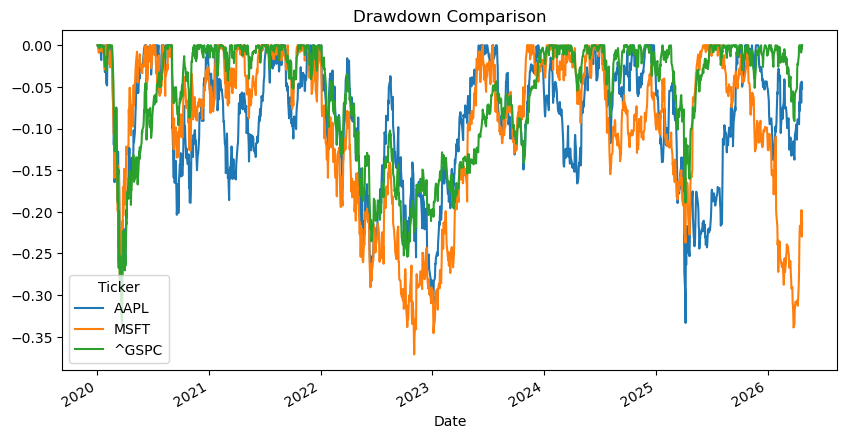

In [16]:
drawdown.plot(figsize=(10,5))
plt.title("Drawdown Comparison")
plt.show()

In [17]:
tickers = ["AAPL", "MSFT", "^GSPC"]


In [20]:
import numpy as np

num_portfolios = 10000

results = []
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    portfolio_return = np.sum(returns.mean() * weights) * 252
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))

    sharpe = portfolio_return / portfolio_volatility

    results.append([portfolio_return, portfolio_volatility, sharpe])
    weights_record.append(weights)

results = np.array(results)

In [21]:
max_sharpe_idx = np.argmax(results[:,2])
best_portfolio = results[max_sharpe_idx]
best_weights = weights_record[max_sharpe_idx]

print("Best Portfolio:")
print("Return:", best_portfolio[0])
print("Volatility:", best_portfolio[1])
print("Sharpe:", best_portfolio[2])
print("Weights:", best_weights)

Best Portfolio:
Return: 0.24109704716551728
Volatility: 0.2856150656415861
Sharpe: 0.8441328072940879
Weights: [0.68504534 0.28242124 0.03253342]


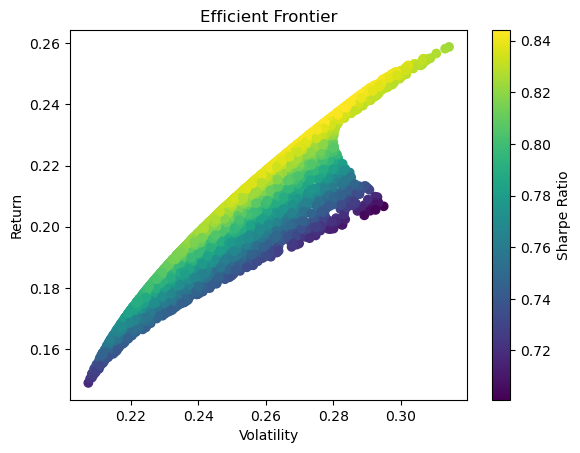

In [22]:
plt.scatter(results[:,1], results[:,0], c=results[:,2], cmap="viridis")
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.show()

In [23]:
optimized_summary = pd.DataFrame({
    "Asset": tickers,
    "Optimal Weight": best_weights
})

optimized_summary

,Asset,Optimal Weight
0,AAPL,0.685045
1,MSFT,0.282421
2,^GSPC,0.032533


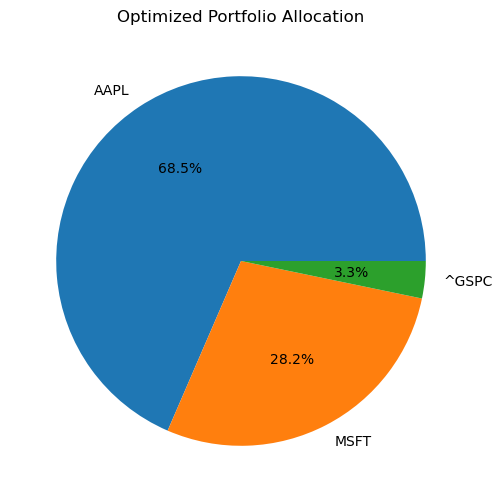

In [24]:
optimized_summary.set_index("Asset").plot.pie(
    y="Optimal Weight",
    figsize=(6,6),
    autopct="%1.1f%%",
    legend=False
)

plt.title("Optimized Portfolio Allocation")
plt.ylabel("")
plt.show()